# 2.2 Impact Model Fitting — rolling-universe baseline only

This notebook completes **Section 2.2** as a continuation of the **enhanced Section 2.1** output.

Important distinction:

- We **do use** the Section 2.1 enhancement: rolling month pairs over the full common stock universe.
- We **do not use** the Section 2.2 enhancement: no non-parametric model, no regularisation, no third sample, and no hyperparameter tuning for regularisation.

So this notebook fits the baseline Section 2.2 models - OW plus one additional parametric model, but it applies them over the rolling full-universe of stocks following part 2.1

The fitted models are:

1. **OW-style transient impact model**
2. **Reduced-form parametric impact model**

DATA USED: The input data is the public binned tape from `binSamples`, not `fillSamples`.

**CONTENT OF THIS NOTEBOOK:**

- rolling OW parameters by pair and stock;
- rolling reduced-form parameters by pair and stock;
- stock-level train/test model metrics;
- pair-level train/test model metrics;
- report summary tables;
- report figures;
- a JSON handoff file for Section 2.3.

## 0. Setup

Run the enhanced/full Section 2.1 notebook first.  
This notebook expects the rolling outputs from Section 2.1 here:

`/content/project_data/processed_2_1/rolling_full_universe`

In [22]:
!pip -q install pyarrow

import os
import gc
import json
import math
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)

In [23]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import shutil
from pathlib import Path

# Local Colab working location
LOCAL_BASE = Path("/content/project_data")

# Permanent Drive backup location
DRIVE_OUTPUT_BASE = Path("/content/drive/MyDrive/Quantitative Trading and Price Impact/project_data")
DRIVE_PROCESSED_21 = DRIVE_OUTPUT_BASE / "processed_2_1"

# Section 2.1 local output locations
SECTION21_DIR = LOCAL_BASE / "processed_2_1"
MONTHLY21_DIR = SECTION21_DIR / "monthly_standardised"
ROLLING21_DIR = SECTION21_DIR / "rolling_full_universe"

# If Section 2.1 outputs are missing locally, restore them from Drive
if not ROLLING21_DIR.exists():
    if DRIVE_PROCESSED_21.exists():
        print("Restoring Section 2.1 outputs from Drive to local Colab storage...")
        shutil.copytree(DRIVE_PROCESSED_21, SECTION21_DIR, dirs_exist_ok=True)
    else:
        raise FileNotFoundError(
            f"Section 2.1 outputs are missing locally and on Drive.\n"
            f"Expected Drive backup here: {DRIVE_PROCESSED_21}\n"
            f"Go back to 2.1 and run the Drive-copy cell first."
        )

# Section 2.2 output locations
SECTION22_DIR = LOCAL_BASE / "processed_2_2_rolling_baseline"
PARAM_DIR = SECTION22_DIR / "parameters"
METRIC_DIR = SECTION22_DIR / "metrics"
REPORT_DIR = SECTION22_DIR / "report_tables"
FIG_DIR = SECTION22_DIR / "figures"
LOG_DIR = SECTION22_DIR / "logs"

for p in [SECTION22_DIR, PARAM_DIR, METRIC_DIR, REPORT_DIR, FIG_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Section 2.1 rolling folder:", ROLLING21_DIR)
print("Section 2.1 monthly folder: ", MONTHLY21_DIR)
print("Section 2.2 output folder:  ", SECTION22_DIR)

print("\nFiles in rolling folder:")
for p in ROLLING21_DIR.glob("*"):
    print(p.name)

Section 2.1 rolling folder: /content/project_data/processed_2_1/rolling_full_universe
Section 2.1 monthly folder:  /content/project_data/processed_2_1/monthly_standardised
Section 2.2 output folder:   /content/project_data/processed_2_2_rolling_baseline

Files in rolling folder:
rolling_pair_summary.csv
rolling_universe_by_pair.csv
global_common_universe_all_months.csv
section_2_1_rolling_config.json


## 1. Load the rolling-universe handoff from Section 2.1

This is where we avoid the earlier mistake.

We do **not** load the 20-stock baseline files.  
We load:

- `rolling_pair_summary.csv`
- `rolling_universe_by_pair.csv`
- monthly standardised `binSamples` Parquet files

For each rolling pair, the stock universe is all stocks common to the train month and the test month.

In [25]:
pair_summary_path = ROLLING21_DIR / "rolling_pair_summary.csv"
universe_path = ROLLING21_DIR / "rolling_universe_by_pair.csv"
rolling_config_path = ROLLING21_DIR / "section_2_1_rolling_config.json"

if not pair_summary_path.exists() or not universe_path.exists():
    raise FileNotFoundError(
        "Could not find Section 2.1 rolling outputs. "
        "Run 2_1_full_as_spec_completed.ipynb first, including the rolling enhancement cells."
    )

pair_summary = pd.read_csv(pair_summary_path)
pair_universe = pd.read_csv(universe_path)

with open(rolling_config_path, "r") as f:
    section21_rolling_config = json.load(f)

pair_summary["train_month"] = pair_summary["train_month"].astype(str)
pair_summary["test_month"] = pair_summary["test_month"].astype(str)
pair_universe["train_month"] = pair_universe["train_month"].astype(str)
pair_universe["test_month"] = pair_universe["test_month"].astype(str)
pair_universe["stock"] = pair_universe["stock"].astype(str)

print("Rolling pairs:")
display(pair_summary)

print("Universe rows:")
display(pair_universe.head())

print("Stocks per pair:")
display(pair_universe.groupby("pair_id")["stock"].nunique().reset_index(name="n_stocks"))

Rolling pairs:


,pair_id,train_month,test_month,train_bin_path,test_bin_path,train_fill_path,test_fill_path,n_train_stocks,n_test_stocks,n_common_stocks_pair_universe,top20_common_stocks_by_train_notional
0,1,201901,201902,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'AMGN', 'ADBE', 'ALGN'..."
1,2,201902,201903,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'AMAT'..."
2,3,201903,201904,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'ALGN'..."
3,4,201904,201905,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'ANTM'..."
4,5,201905,201906,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'APC',..."
5,6,201906,201907,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'AGN',..."
6,7,201907,201908,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,50,50,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'AGN',..."
7,8,201908,201909,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,50,49,49,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'ADSK'..."
8,9,201909,201910,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,49,49,49,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'ADP',..."
9,10,201910,201911,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,/content/project_data/processed_2_1/monthly_st...,49,49,49,"['AMZN', 'AAPL', 'AMD', 'ADBE', 'AMGN', 'AMAT'..."


Universe rows:


,stock,train_total_abs_notional,train_n_rows,train_n_trading_days,test_total_abs_notional,test_n_rows,test_n_trading_days,pair_id,train_month,test_month
0,AMZN,2.185694e+10,46814,21,1.408750e+10,44284,19,1,201901,201902
1,AAPL,9.531554e+09,46860,21,6.306262e+09,44460,19,1,201901,201902
2,AMD,3.953044e+09,46858,21,3.038560e+09,44460,19,1,201901,201902
3,AMGN,2.225017e+09,46459,21,1.654364e+09,43637,19,1,201901,201902
4,ADBE,2.067497e+09,46392,21,1.802948e+09,43761,19,1,201901,201902


Stocks per pair:


,pair_id,n_stocks
0,1,50
1,2,50
2,3,50
3,4,50
4,5,50
5,6,50
6,7,50
7,8,49
8,9,49
9,10,49


In [26]:
# Safety check: this notebook must continue from the enhanced rolling structure, not the 20-stock baseline.
n_stocks_by_pair = pair_universe.groupby("pair_id")["stock"].nunique()
print(n_stocks_by_pair.describe())

assert len(pair_summary) >= 1, "Need at least one rolling pair."
assert n_stocks_by_pair.min() > 20, (
    "The rolling universe has 20 or fewer stocks in at least one pair. "
    "Check that you are using the full rolling-universe output from Section 2.1, not the 20-stock baseline."
)

print("Confirmed: using rolling full-universe pairs, not the fixed 20-stock baseline.")

count    11.000000
mean     49.636364
std       0.504525
min      49.000000
25%      49.000000
50%      50.000000
75%      50.000000
max      50.000000
Name: stock, dtype: float64
Confirmed: using rolling full-universe pairs, not the fixed 20-stock baseline.


## 2. Modelling design

For each rolling pair:

- train month = in-sample month;
- test month = next out-of-sample month;
- universe = all stocks common to both months;
- models are fitted using only the train month;
- fitted parameters are evaluated on both the train and test month.

This produces one set of fitted model parameters per:

`pair_id`, `stock`, `model`.

This is still baseline Section 2.2 because the models are parametric and there is no regularisation or third sample.

In [27]:
# Main run controls.
# Leave these as None for the final project run.
RUN_PAIR_IDS: Optional[List[int]] = None       # example for debugging only: [1]
MAX_STOCKS_PER_PAIR: Optional[int] = None     # keep None for full universe; do not set to 20

# Minimum data needed to fit a stock-level model.
MIN_TRAIN_ROWS_PER_STOCK = 100
MIN_TEST_ROWS_PER_STOCK = 20

# OW half-life candidates in seconds.
OW_HALF_LIFE_GRID_SEC = [30, 60, 120, 300, 600, 1200, 1800]

# Reduced-form model features.
REDUCED_FORM_FEATURES = [
    "x_flow",
    "x_trade",
    "x_hidden",
    "x_flow_depth",
    "lobImb",
    "effLobImb",
    "spread_bps",
]

# Columns needed from the Section 2.1 monthly standardised binSamples.
BIN_COLUMNS_NEEDED = [
    "date", "time", "stock", "trade", "orderFlow", "hidden", "auction",
    "mid", "midEnd", "spread", "lobImb", "effLobImb", "depth",
    "datetime", "trading_date", "seconds_from_open"
]

## 3. Data-loading utilities

The monthly Parquet files created in Section 2.1 are the main input.  
We filter to the rolling pair's common stock universe after loading.

In [28]:
def monthly_bin_path(month: str) -> Path:
    """Return the Section 2.1 standardised binSamples Parquet path for one month."""
    return MONTHLY21_DIR / "bin" / f"bin_{str(month)}_standardised.parquet"


def load_bin_month_for_universe(month: str, stocks: List[str], columns: Optional[List[str]] = None) -> pd.DataFrame:
    """
    Load one standardised binSamples month and filter to the requested stock universe.

    This uses the monthly Parquet from Section 2.1. It does not select top-20 stocks.
    """
    path = monthly_bin_path(month)
    if not path.exists():
        raise FileNotFoundError(f"Missing monthly bin Parquet for {month}: {path}")

    use_cols = columns if columns is not None else None

    # Try Parquet predicate pushdown. If it is unavailable for this file, fall back safely.
    try:
        df = pd.read_parquet(path, columns=use_cols, filters=[("stock", "in", list(stocks))])
    except Exception:
        df = pd.read_parquet(path, columns=use_cols)
        df["stock"] = df["stock"].astype(str)
        df = df[df["stock"].isin(set(stocks))].copy()

    df["stock"] = df["stock"].astype(str)
    return df.reset_index(drop=True)



def get_pair_stock_universe(pair_id: int) -> List[str]:
    """Return the full common stock universe for a rolling pair."""
    stocks = (
        pair_universe.loc[pair_universe["pair_id"] == pair_id, "stock"]
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )
    if MAX_STOCKS_PER_PAIR is not None:
        # This is only for debugging. Do not use this for the final run.
        stocks = stocks[:MAX_STOCKS_PER_PAIR]
    return stocks

## 4. Build modelling variables

The target is the within-bin mid-price move in basis points:

$$
y_t = 10{,}000 \times \frac{midEnd_t - mid_t}{mid_t}.$$

The main signed trading variable is `orderFlow`, because it is the public signed order-flow variable in the binned tape.

In [29]:
def make_seconds_from_open(df: pd.DataFrame) -> pd.Series:
    """Create seconds since 09:30 when Section 2.1 did not already save it."""
    dt = pd.to_datetime(df["datetime"])
    open_time = pd.to_datetime(dt.dt.date.astype(str) + " 09:30:00")
    return (dt - open_time).dt.total_seconds().astype("float64")


def compute_training_scales(train_df: pd.DataFrame) -> Dict:
    """
    Compute stock-level training scales used to normalise order-flow variables.

    These are computed from the train month only and then reused for the test month.
    """
    tmp = train_df.copy()
    tmp["stock"] = tmp["stock"].astype(str)
    tmp["trading_date"] = tmp["trading_date"].astype(str)
    tmp["abs_orderFlow"] = pd.to_numeric(tmp["orderFlow"], errors="coerce").abs()

    daily_abs_flow = (
        tmp.groupby(["stock", "trading_date"], observed=True)["abs_orderFlow"]
        .sum()
        .reset_index(name="daily_abs_orderFlow")
    )

    stock_flow_scale = (
        daily_abs_flow.groupby("stock", observed=True)["daily_abs_orderFlow"]
        .median()
        .replace(0, np.nan)
    )

    global_flow_scale = float(np.nanmedian(stock_flow_scale.values))
    if not np.isfinite(global_flow_scale) or global_flow_scale <= 0:
        global_flow_scale = 1.0

    stock_flow_scale = stock_flow_scale.fillna(global_flow_scale).to_dict()

    median_depth = (
        tmp.groupby("stock", observed=True)["depth"]
        .median()
        .replace(0, np.nan)
    )

    global_depth_scale = float(np.nanmedian(median_depth.values))
    if not np.isfinite(global_depth_scale) or global_depth_scale <= 0:
        global_depth_scale = 1.0

    median_depth = median_depth.fillna(global_depth_scale).to_dict()

    return {
        "stock_flow_scale": {str(k): float(v) for k, v in stock_flow_scale.items()},
        "global_flow_scale": float(global_flow_scale),
        "stock_depth_scale": {str(k): float(v) for k, v in median_depth.items()},
        "global_depth_scale": float(global_depth_scale),
    }


def prepare_model_frame(df: pd.DataFrame, scales: Dict) -> pd.DataFrame:
    """Create the modelling variables used by both baseline Section 2.2 models."""
    out = df.copy()

    out["stock"] = out["stock"].astype(str)
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out["trading_date"] = out["trading_date"].astype(str)

    if "seconds_from_open" not in out.columns:
        out["seconds_from_open"] = make_seconds_from_open(out)

    # Minimal required filtering for model fitting.
    out = out[out["datetime"].notna()].copy()
    out = out[(out["mid"] > 0) & (out["midEnd"] > 0)].copy()
    out = out.replace([np.inf, -np.inf], np.nan)

    # Target: within-bin mid-price move in basis points.
    out["ret_bps"] = 10000.0 * (out["midEnd"] - out["mid"]) / out["mid"]

    # Stock-level flow normalisation from the train month.
    flow_scale_map = scales["stock_flow_scale"]
    depth_scale_map = scales["stock_depth_scale"]

    out["flow_scale"] = out["stock"].map(flow_scale_map).fillna(scales["global_flow_scale"]).astype(float)
    out["depth_scale"] = out["stock"].map(depth_scale_map).fillna(scales["global_depth_scale"]).astype(float)

    # Signed flow variables.
    out["x_flow"] = pd.to_numeric(out["orderFlow"], errors="coerce") / out["flow_scale"]
    out["x_trade"] = pd.to_numeric(out["trade"], errors="coerce") / out["flow_scale"]
    out["x_hidden"] = pd.to_numeric(out["hidden"], errors="coerce") / out["flow_scale"]
    out["x_auction"] = pd.to_numeric(out["auction"], errors="coerce") / out["flow_scale"]

    # Liquidity and book-state variables.
    out["spread_bps"] = 10000.0 * pd.to_numeric(out["spread"], errors="coerce") / out["mid"]
    out["x_flow_depth"] = pd.to_numeric(out["orderFlow"], errors="coerce") / pd.to_numeric(out["depth"], errors="coerce").replace(0, np.nan)
    out["x_trade_depth"] = pd.to_numeric(out["trade"], errors="coerce") / pd.to_numeric(out["depth"], errors="coerce").replace(0, np.nan)

    # Fill feature gaps with zero. Keep target finite.
    feature_cols_to_fill = [
        "x_flow", "x_trade", "x_hidden", "x_auction",
        "spread_bps", "x_flow_depth", "x_trade_depth",
        "lobImb", "effLobImb", "depth"
    ]

    for c in feature_cols_to_fill:
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)

    out = out[np.isfinite(out["ret_bps"])].copy()
    out = out.sort_values(["stock", "trading_date", "datetime"]).reset_index(drop=True)
    return out

## 5. OLS and metric utilities

Both baseline models are fitted by ordinary least squares (since we don't do enhancement, i.e. no non-parametric fitting nor regularization)

In [30]:
def fit_ols(df: pd.DataFrame, y_col: str, x_cols: List[str]) -> Dict:
    """Fit y = intercept + X beta by least squares."""
    use_cols = [y_col] + x_cols
    d = df[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(d) < len(x_cols) + 5:
        raise ValueError(f"Not enough rows to fit OLS with features {x_cols}. Rows={len(d)}")

    y = d[y_col].to_numpy(dtype=float)
    X = d[x_cols].to_numpy(dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])

    coef, *_ = np.linalg.lstsq(X_design, y, rcond=None)

    coef_dict = {"intercept": float(coef[0])}
    coef_dict.update({name: float(value) for name, value in zip(x_cols, coef[1:])})

    return {"coef": coef_dict}


def predict_ols(df: pd.DataFrame, coef: Dict, x_cols: List[str]) -> np.ndarray:
    """Predict using a coefficient dictionary produced by fit_ols."""
    X = df[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=float)
    pred = np.full(len(df), float(coef.get("intercept", 0.0)))
    for j, c in enumerate(x_cols):
        pred += float(coef.get(c, 0.0)) * X[:, j]
    return pred


def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    """Return standard regression metrics."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return {
            "n": 0,
            "rmse": np.nan,
            "mae": np.nan,
            "r2": np.nan,
            "corr": np.nan,
            "mean_error": np.nan,
        }

    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = np.nan

    return {
        "n": int(len(y_true)),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "mean_error": float(np.mean(err)),
    }


class MetricAccumulator:
    """Accumulate overall metrics without storing all row-level predictions."""
    def __init__(self):
        self.n = 0
        self.sum_y = 0.0
        self.sum_y2 = 0.0
        self.sum_pred = 0.0
        self.sum_pred2 = 0.0
        self.sum_y_pred = 0.0
        self.sum_err = 0.0
        self.sum_abs_err = 0.0
        self.sum_sq_err = 0.0

    def update(self, y, pred):
        y = np.asarray(y, dtype=float)
        pred = np.asarray(pred, dtype=float)
        mask = np.isfinite(y) & np.isfinite(pred)
        y = y[mask]
        pred = pred[mask]
        if len(y) == 0:
            return

        err = y - pred
        self.n += int(len(y))
        self.sum_y += float(np.sum(y))
        self.sum_y2 += float(np.sum(y ** 2))
        self.sum_pred += float(np.sum(pred))
        self.sum_pred2 += float(np.sum(pred ** 2))
        self.sum_y_pred += float(np.sum(y * pred))
        self.sum_err += float(np.sum(err))
        self.sum_abs_err += float(np.sum(np.abs(err)))
        self.sum_sq_err += float(np.sum(err ** 2))

    def compute(self) -> Dict[str, float]:
        if self.n == 0:
            return {"n": 0, "rmse": np.nan, "mae": np.nan, "r2": np.nan, "corr": np.nan, "mean_error": np.nan}

        n = self.n
        mean_y = self.sum_y / n
        mean_pred = self.sum_pred / n

        rmse = math.sqrt(self.sum_sq_err / n)
        mae = self.sum_abs_err / n
        mean_error = self.sum_err / n

        ss_tot = self.sum_y2 - n * mean_y ** 2
        r2 = 1.0 - self.sum_sq_err / ss_tot if ss_tot > 0 else np.nan

        cov = self.sum_y_pred - n * mean_y * mean_pred
        var_y = self.sum_y2 - n * mean_y ** 2
        var_pred = self.sum_pred2 - n * mean_pred ** 2
        corr = cov / math.sqrt(var_y * var_pred) if var_y > 0 and var_pred > 0 else np.nan

        return {
            "n": int(n),
            "rmse": float(rmse),
            "mae": float(mae),
            "r2": float(r2) if np.isfinite(r2) else np.nan,
            "corr": float(corr) if np.isfinite(corr) else np.nan,
            "mean_error": float(mean_error),
        }

## 6. Model 1: OW style transient impact model

Discrete OW-style state:
$$
S_t = \phi_t S_{t-1} + x_t,
\qquad
\phi_t = \exp(-\Delta t / \tau).$$

The fitted equation is:

$$
y_t = a + \beta_{flow}x_t + \beta_{state}S_{t^-} + \epsilon_t.$$

The state resets at the start of each trading day, matching the baseline simulator assumption in Section 2.3.

In [31]:
def add_ow_state_one_stock(df: pd.DataFrame, half_life_sec: float, flow_col: str = "x_flow") -> pd.DataFrame:
    """Add the pre-trade OW state for one stock, with daily resets."""
    out = df.sort_values(["trading_date", "datetime"]).reset_index(drop=True).copy()

    state_pre = np.zeros(len(out), dtype=float)
    state_post = np.zeros(len(out), dtype=float)

    for _, positions in out.groupby("trading_date", observed=True, sort=False).indices.items():
        positions = np.asarray(positions, dtype=int)
        sub = out.iloc[positions]
        seconds = sub["seconds_from_open"].to_numpy(dtype=float)
        flows = sub[flow_col].to_numpy(dtype=float)

        prev_state = 0.0
        prev_sec = None

        for k, pos in enumerate(positions):
            if prev_sec is None:
                dt = 0.0
            else:
                dt = max(float(seconds[k] - prev_sec), 0.0)

            phi = math.exp(-dt / half_life_sec) if half_life_sec > 0 else 0.0
            pre = phi * prev_state
            post = pre + flows[k]

            state_pre[pos] = pre
            state_post[pos] = post

            prev_state = post
            prev_sec = seconds[k]

    out["ow_state_pre"] = state_pre
    out["ow_state_post"] = state_post
    return out


def fit_ow_for_stock(train_stock: pd.DataFrame, half_life_grid: List[float]) -> Dict:
    """Choose the OW half-life by train RMSE and fit the final OW coefficients."""
    best = None
    x_cols = ["x_flow", "ow_state_pre"]

    for hl in half_life_grid:
        with_state = add_ow_state_one_stock(train_stock, half_life_sec=hl)
        fit = fit_ols(with_state, "ret_bps", x_cols)
        pred = predict_ols(with_state, fit["coef"], x_cols)
        metrics = regression_metrics(with_state["ret_bps"], pred)

        candidate = {
            "half_life_sec": float(hl),
            "coef": fit["coef"],
            "metrics": metrics,
        }

        if best is None or candidate["metrics"]["rmse"] < best["metrics"]["rmse"]:
            best = candidate

    return best

## 7. Model 2: reduced form parametric impact model

The second baseline model is a richer parametric regression:

$$
y_t = a + b_1x^{flow}_t + b_2x^{trade}_t + b_3x^{hidden}_t
+ b_4\frac{orderFlow_t}{depth_t}
+ b_5lobImb_t + b_6effLobImb_t + b_7spreadBps_t + \epsilon_t.$$

This is the additional baseline model. It is not the non-parametric/regularised Section 2.2 enhancement.

In [32]:
def fit_reduced_form_for_stock(train_stock: pd.DataFrame) -> Dict:
    """Fit the reduced-form parametric model for one stock."""
    fit = fit_ols(train_stock, "ret_bps", REDUCED_FORM_FEATURES)
    return {"coef": fit["coef"]}

## 8. Rolling fitting loop

This is the main Section 2.2 run.

It loops through all rolling pairs from Section 2.1.  
For each pair, it uses the whole common stock universe for that pair.

Nothing in this cell selects 20 stocks.

In [33]:
def process_one_pair(pair_row: pd.Series) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Fit OW and reduced-form baseline models for one rolling pair.

    Returns:
    - parameter rows
    - stock-level metric rows
    - pair-level overall metric rows
    """
    pair_id = int(pair_row["pair_id"])
    train_month = str(pair_row["train_month"])
    test_month = str(pair_row["test_month"])

    stocks = get_pair_stock_universe(pair_id)
    print(f"\nPair {pair_id}: {train_month} -> {test_month}")
    print(f"Full common universe size: {len(stocks)}")

    if len(stocks) == 0:
        raise ValueError(f"No stocks found for pair_id={pair_id}")

    train_raw = load_bin_month_for_universe(train_month, stocks, columns=BIN_COLUMNS_NEEDED)
    test_raw = load_bin_month_for_universe(test_month, stocks, columns=BIN_COLUMNS_NEEDED)

    print("Loaded train:", train_raw.shape)
    print("Loaded test: ", test_raw.shape)

    scales = compute_training_scales(train_raw)
    train = prepare_model_frame(train_raw, scales)
    test = prepare_model_frame(test_raw, scales)

    common_after_clean = sorted(set(train["stock"].unique()) & set(test["stock"].unique()) & set(stocks))
    print("Common stocks after minimal model cleaning:", len(common_after_clean))

    param_rows = []
    metric_rows = []
    failure_rows = []

    overall_acc = {
        ("OW_transient", "train"): MetricAccumulator(),
        ("OW_transient", "test"): MetricAccumulator(),
        ("reduced_form", "train"): MetricAccumulator(),
        ("reduced_form", "test"): MetricAccumulator(),
    }

    train_groups = {str(k): v.reset_index(drop=True) for k, v in train.groupby("stock", observed=True, sort=False)}
    test_groups = {str(k): v.reset_index(drop=True) for k, v in test.groupby("stock", observed=True, sort=False)}

    for j, stock in enumerate(common_after_clean, start=1):
        if j % 25 == 0 or j == 1 or j == len(common_after_clean):
            print(f"  fitting stock {j}/{len(common_after_clean)}: {stock}")

        tr = train_groups.get(stock, pd.DataFrame())
        te = test_groups.get(stock, pd.DataFrame())

        if len(tr) < MIN_TRAIN_ROWS_PER_STOCK or len(te) < MIN_TEST_ROWS_PER_STOCK:
            failure_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "stock": stock,
                "reason": "insufficient_rows",
                "train_rows": len(tr),
                "test_rows": len(te),
            })
            continue

        # Model 1: OW transient impact.
        try:
            ow_fit = fit_ow_for_stock(tr, OW_HALF_LIFE_GRID_SEC)
            ow_coef = ow_fit["coef"]
            ow_hl = ow_fit["half_life_sec"]

            tr_ow = add_ow_state_one_stock(tr, ow_hl)
            te_ow = add_ow_state_one_stock(te, ow_hl)

            ow_features = ["x_flow", "ow_state_pre"]
            tr_pred = predict_ols(tr_ow, ow_coef, ow_features)
            te_pred = predict_ols(te_ow, ow_coef, ow_features)

            tr_metrics = regression_metrics(tr_ow["ret_bps"], tr_pred)
            te_metrics = regression_metrics(te_ow["ret_bps"], te_pred)

            overall_acc[("OW_transient", "train")].update(tr_ow["ret_bps"], tr_pred)
            overall_acc[("OW_transient", "test")].update(te_ow["ret_bps"], te_pred)

            param_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "model": "OW_transient",
                "stock": stock,
                "half_life_sec": ow_hl,
                **ow_coef,
            })

            metric_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "model": "OW_transient",
                "stock": stock,
                "sample": "train",
                **tr_metrics,
            })
            metric_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "model": "OW_transient",
                "stock": stock,
                "sample": "test",
                **te_metrics,
            })

        except Exception as e:
            failure_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "stock": stock,
                "model": "OW_transient",
                "reason": repr(e),
                "train_rows": len(tr),
                "test_rows": len(te),
            })

        # Model 2: reduced-form parametric model.
        try:
            rf_fit = fit_reduced_form_for_stock(tr)
            rf_coef = rf_fit["coef"]

            tr_pred = predict_ols(tr, rf_coef, REDUCED_FORM_FEATURES)
            te_pred = predict_ols(te, rf_coef, REDUCED_FORM_FEATURES)

            tr_metrics = regression_metrics(tr["ret_bps"], tr_pred)
            te_metrics = regression_metrics(te["ret_bps"], te_pred)

            overall_acc[("reduced_form", "train")].update(tr["ret_bps"], tr_pred)
            overall_acc[("reduced_form", "test")].update(te["ret_bps"], te_pred)

            param_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "model": "reduced_form",
                "stock": stock,
                "half_life_sec": np.nan,
                **rf_coef,
            })

            metric_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "model": "reduced_form",
                "stock": stock,
                "sample": "train",
                **tr_metrics,
            })
            metric_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "model": "reduced_form",
                "stock": stock,
                "sample": "test",
                **te_metrics,
            })

        except Exception as e:
            failure_rows.append({
                "pair_id": pair_id,
                "train_month": train_month,
                "test_month": test_month,
                "stock": stock,
                "model": "reduced_form",
                "reason": repr(e),
                "train_rows": len(tr),
                "test_rows": len(te),
            })

    overall_rows = []
    for (model, sample), acc in overall_acc.items():
        overall_rows.append({
            "pair_id": pair_id,
            "train_month": train_month,
            "test_month": test_month,
            "model": model,
            "sample": sample,
            **acc.compute(),
        })

    params_df = pd.DataFrame(param_rows)
    metrics_df = pd.DataFrame(metric_rows)
    overall_df = pd.DataFrame(overall_rows)
    failures_df = pd.DataFrame(failure_rows)

    # Save pair-level outputs immediately, so a long run is not lost if Colab disconnects.
    params_df.to_csv(PARAM_DIR / f"params_pair_{pair_id:02d}_{train_month}_to_{test_month}.csv", index=False)
    metrics_df.to_csv(METRIC_DIR / f"stock_metrics_pair_{pair_id:02d}_{train_month}_to_{test_month}.csv", index=False)
    overall_df.to_csv(METRIC_DIR / f"overall_metrics_pair_{pair_id:02d}_{train_month}_to_{test_month}.csv", index=False)
    failures_df.to_csv(LOG_DIR / f"failures_pair_{pair_id:02d}_{train_month}_to_{test_month}.csv", index=False)

    print("Saved pair outputs.")
    print("Fitted parameter rows:", len(params_df))
    print("Stock metric rows:    ", len(metrics_df))
    print("Failure rows:         ", len(failures_df))

    # Free memory before the next pair.
    del train_raw, test_raw, train, test, train_groups, test_groups
    gc.collect()

    return params_df, metrics_df, overall_df

In [34]:
# Select rolling pairs to run.
pairs_to_run = pair_summary.copy()

if RUN_PAIR_IDS is not None:
    pairs_to_run = pairs_to_run[pairs_to_run["pair_id"].isin(RUN_PAIR_IDS)].copy()

print("Pairs to run:")
display(pairs_to_run[["pair_id", "train_month", "test_month"]])

all_param_parts = []
all_metric_parts = []
all_overall_parts = []

for _, pair_row in pairs_to_run.iterrows():
    params_df, metrics_df, overall_df = process_one_pair(pair_row)

    all_param_parts.append(params_df)
    all_metric_parts.append(metrics_df)
    all_overall_parts.append(overall_df)

    # Save combined outputs after every pair.
    combined_params = pd.concat(all_param_parts, ignore_index=True) if all_param_parts else pd.DataFrame()
    combined_metrics = pd.concat(all_metric_parts, ignore_index=True) if all_metric_parts else pd.DataFrame()
    combined_overall = pd.concat(all_overall_parts, ignore_index=True) if all_overall_parts else pd.DataFrame()

    combined_params.to_csv(PARAM_DIR / "section_2_2_rolling_baseline_params_all_pairs.csv", index=False)
    combined_metrics.to_csv(METRIC_DIR / "section_2_2_rolling_baseline_stock_metrics_all_pairs.csv", index=False)
    combined_overall.to_csv(METRIC_DIR / "section_2_2_rolling_baseline_overall_metrics_all_pairs.csv", index=False)

print("Rolling Section 2.2 fitting complete.")

Pairs to run:


,pair_id,train_month,test_month
0,1,201901,201902
1,2,201902,201903
2,3,201903,201904
3,4,201904,201905
4,5,201905,201906
5,6,201906,201907
6,7,201907,201908
7,8,201908,201909
8,9,201909,201910
9,10,201910,201911



Pair 1: 201901 -> 201902
Full common universe size: 50
Loaded train: (2168002, 16)
Loaded test:  (2018914, 16)
Common stocks after minimal model cleaning: 50
  fitting stock 1/50: A
  fitting stock 25/50: AKAM
  fitting stock 50/50: ARE
Saved pair outputs.
Fitted parameter rows: 100
Stock metric rows:     200
Failure rows:          0

Pair 2: 201902 -> 201903
Full common universe size: 50
Loaded train: (2018914, 16)
Loaded test:  (2258058, 16)
Common stocks after minimal model cleaning: 50
  fitting stock 1/50: A
  fitting stock 25/50: AKAM
  fitting stock 50/50: ARE
Saved pair outputs.
Fitted parameter rows: 100
Stock metric rows:     200
Failure rows:          0

Pair 3: 201903 -> 201904
Full common universe size: 50
Loaded train: (2258058, 16)
Loaded test:  (2185122, 16)
Common stocks after minimal model cleaning: 50
  fitting stock 1/50: A
  fitting stock 25/50: AKAM
  fitting stock 50/50: ARE
Saved pair outputs.
Fitted parameter rows: 100
Stock metric rows:     200
Failure rows: 

## 9. Inspect fitted parameters and metrics

In [35]:
params_all = pd.read_csv(PARAM_DIR / "section_2_2_rolling_baseline_params_all_pairs.csv")
stock_metrics_all = pd.read_csv(METRIC_DIR / "section_2_2_rolling_baseline_stock_metrics_all_pairs.csv")
overall_metrics_all = pd.read_csv(METRIC_DIR / "section_2_2_rolling_baseline_overall_metrics_all_pairs.csv")

print("All parameter rows:", params_all.shape)
display(params_all.head())

print("Overall rolling metrics:")
display(overall_metrics_all)

print("Stock-level metrics sample:")
display(stock_metrics_all.head())

All parameter rows: (1092, 15)


,pair_id,train_month,test_month,model,stock,half_life_sec,intercept,x_flow,ow_state_pre,x_trade,x_hidden,x_flow_depth,lobImb,effLobImb,spread_bps
0,1,201901,201902,OW_transient,A,1800.0,0.061743,167.390953,1.852045,NaN,NaN,NaN,NaN,NaN,NaN
1,1,201901,201902,reduced_form,A,NaN,-0.061747,186.694998,NaN,-114.625991,-567.406033,-0.000532,0.442003,0.038193,0.057225
2,1,201901,201902,OW_transient,AAL,60.0,-0.097961,962.578316,47.455393,NaN,NaN,NaN,NaN,NaN,NaN
3,1,201901,201902,reduced_form,AAL,NaN,-0.158986,134.805581,NaN,462.487907,-358.235124,0.170464,0.618070,0.069178,0.039948
4,1,201901,201902,OW_transient,AAP,60.0,0.041398,129.971500,23.288254,NaN,NaN,NaN,NaN,NaN,NaN


Overall rolling metrics:


,pair_id,train_month,test_month,model,sample,n,rmse,mae,r2,corr,mean_error
0,1,201901,201902,OW_transient,train,2168002,2.404750,1.110225,0.022125,0.148745,-4.257476e-16
1,1,201901,201902,OW_transient,test,2018914,1.719064,0.769384,0.018627,0.147684,-2.625155e-04
2,1,201901,201902,reduced_form,train,2168002,2.382250,1.142612,0.040339,0.200845,-2.750280e-14
3,1,201901,201902,reduced_form,test,2018914,1.709610,0.811632,0.029391,0.187983,-8.844648e-03
4,2,201902,201903,OW_transient,train,2018914,1.714686,0.746945,0.023620,0.153687,3.284015e-16
5,2,201902,201903,OW_transient,test,2258058,1.569775,0.733014,0.024044,0.155474,-5.896738e-03
6,2,201902,201903,reduced_form,train,2018914,1.698382,0.776063,0.042099,0.205181,-1.257273e-14
7,2,201902,201903,reduced_form,test,2258058,1.556558,0.762763,0.040409,0.202324,-8.604015e-03
8,3,201903,201904,OW_transient,train,2258058,1.567832,0.732221,0.026458,0.162660,-1.061043e-15
9,3,201903,201904,OW_transient,test,2185122,1.575805,0.682470,0.018900,0.138097,8.345490e-03


Stock-level metrics sample:


,pair_id,train_month,test_month,model,stock,sample,n,rmse,mae,r2,corr,mean_error
0,1,201901,201902,OW_transient,A,train,43405,2.024805,0.979844,0.005281,0.072673,-2.115013e-15
1,1,201901,201902,OW_transient,A,test,40871,1.372494,0.604899,-0.001441,0.054142,-5.266740e-02
2,1,201901,201902,reduced_form,A,train,43405,2.006674,1.000736,0.023015,0.151708,-3.404581e-14
3,1,201901,201902,reduced_form,A,test,40871,1.378574,0.642101,-0.010333,0.080034,-5.031956e-03
4,1,201901,201902,OW_transient,AAL,train,46782,2.667418,1.452846,0.065223,0.255388,-2.865136e-15


In [36]:
# Separate parameter files by model for easier Section 2.3 loading.
ow_params = params_all[params_all["model"] == "OW_transient"].copy()
rf_params = params_all[params_all["model"] == "reduced_form"].copy()

ow_params.to_csv(PARAM_DIR / "ow_transient_params_by_pair_stock.csv", index=False)
rf_params.to_csv(PARAM_DIR / "reduced_form_params_by_pair_stock.csv", index=False)

print("OW params:", ow_params.shape)
print("Reduced-form params:", rf_params.shape)

OW params: (546, 15)
Reduced-form params: (546, 15)


## 10. Summary tables and figures (needed for report)

In [37]:
# Table: average out-of-sample performance across rolling pairs.
test_overall = overall_metrics_all[overall_metrics_all["sample"] == "test"].copy()

summary_by_model = (
    test_overall.groupby("model", observed=True)
    .agg(
        n_pairs=("pair_id", "nunique"),
        total_test_rows=("n", "sum"),
        avg_test_rmse=("rmse", "mean"),
        median_test_rmse=("rmse", "median"),
        avg_test_mae=("mae", "mean"),
        avg_test_r2=("r2", "mean"),
        avg_test_corr=("corr", "mean"),
    )
    .reset_index()
)

summary_by_model.to_csv(REPORT_DIR / "section_2_2_rolling_baseline_summary_by_model.csv", index=False)
display(summary_by_model)

,model,n_pairs,total_test_rows,avg_test_rmse,median_test_rmse,avg_test_mae,avg_test_r2,avg_test_corr
0,OW_transient,11,23670124,1.700254,1.719064,0.759964,0.016716,0.131108
1,reduced_form,11,23670124,1.685504,1.709610,0.792575,0.033699,0.186648


In [38]:
# Table: pair-by-pair out-of-sample comparison.
pair_model_comparison = (
    test_overall[["pair_id", "train_month", "test_month", "model", "n", "rmse", "mae", "r2", "corr"]]
    .sort_values(["pair_id", "model"])
    .reset_index(drop=True)
)

pair_model_comparison.to_csv(REPORT_DIR / "section_2_2_pair_model_comparison.csv", index=False)
display(pair_model_comparison)

,pair_id,train_month,test_month,model,n,rmse,mae,r2,corr
0,1,201901,201902,OW_transient,2018914,1.719064,0.769384,0.018627,0.147684
1,1,201901,201902,reduced_form,2018914,1.709610,0.811632,0.029391,0.187983
2,2,201902,201903,OW_transient,2258058,1.569775,0.733014,0.024044,0.155474
3,2,201902,201903,reduced_form,2258058,1.556558,0.762763,0.040409,0.202324
4,3,201903,201904,OW_transient,2185122,1.575805,0.682470,0.018900,0.138097
5,3,201903,201904,reduced_form,2185122,1.562546,0.709749,0.035341,0.190190
6,4,201904,201905,OW_transient,2364583,1.776868,0.822271,0.024027,0.157603
7,4,201904,201905,reduced_form,2364583,1.763794,0.847268,0.038337,0.195995
8,5,201905,201906,OW_transient,2103978,1.615768,0.736038,0.018684,0.145022
9,5,201905,201906,reduced_form,2103978,1.600519,0.766201,0.037120,0.198260


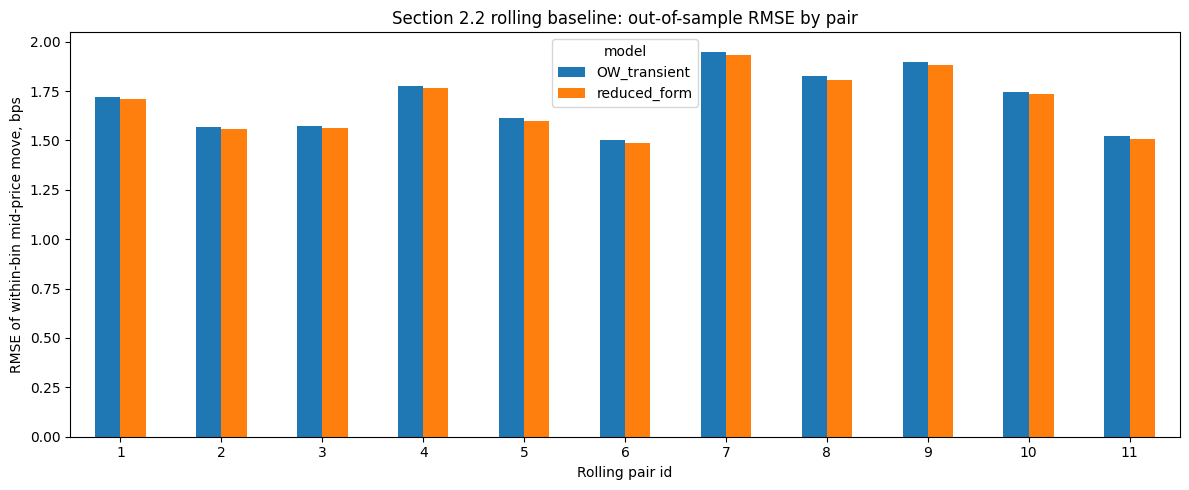

In [39]:
# Figure 1: out-of-sample RMSE by rolling pair.
rmse_pivot = test_overall.pivot(index="pair_id", columns="model", values="rmse").sort_index()

ax = rmse_pivot.plot(kind="bar", figsize=(12, 5))
ax.set_title("Section 2.2 rolling baseline: out-of-sample RMSE by pair")
ax.set_xlabel("Rolling pair id")
ax.set_ylabel("RMSE of within-bin mid-price move, bps")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "rolling_test_rmse_by_pair.png", dpi=150)
plt.show()

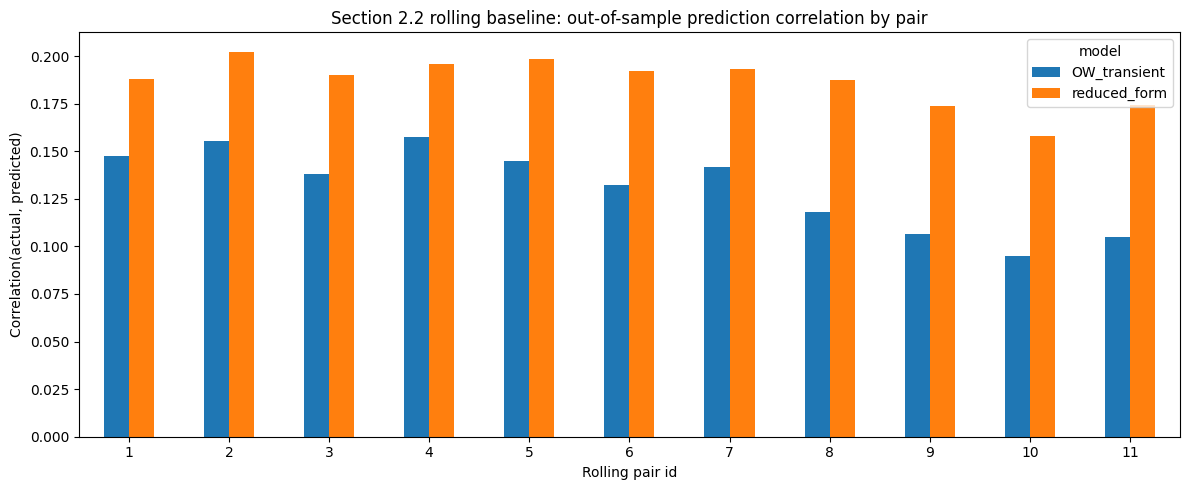

In [40]:
# Figure 2: out-of-sample correlation by rolling pair.
corr_pivot = test_overall.pivot(index="pair_id", columns="model", values="corr").sort_index()

ax = corr_pivot.plot(kind="bar", figsize=(12, 5))
ax.set_title("Section 2.2 rolling baseline: out-of-sample prediction correlation by pair")
ax.set_xlabel("Rolling pair id")
ax.set_ylabel("Correlation(actual, predicted)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "rolling_test_corr_by_pair.png", dpi=150)
plt.show()

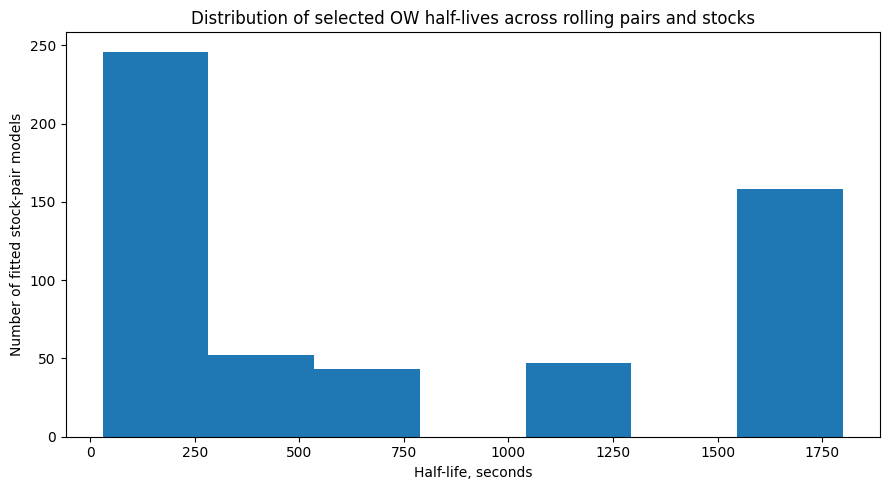

In [41]:
# Figure 3: fitted OW half-life distribution.
if "half_life_sec" in ow_params.columns and len(ow_params) > 0:
    ax = ow_params["half_life_sec"].dropna().plot(kind="hist", bins=len(OW_HALF_LIFE_GRID_SEC), figsize=(9, 5))
    ax.set_title("Distribution of selected OW half-lives across rolling pairs and stocks")
    ax.set_xlabel("Half-life, seconds")
    ax.set_ylabel("Number of fitted stock-pair models")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ow_half_life_distribution.png", dpi=150)
    plt.show()
else:
    print("No OW half-life values available to plot.")

## 11. Handoff to Section 2.3

Section 2.3 can use these fitted parameters for the Waelbroeck-style simulator.

The important handoff is:

- for each rolling pair, train month and test month;
- stock universe for that pair;
- OW parameters by `pair_id` and `stock`;
- reduced-form parameters by `pair_id` and `stock`;
- confirmation that impact states should reset daily in the baseline simulator.

In [42]:
handoff = {
    "section": "2.2 Impact Model Fitting rolling-universe baseline",
    "continues_from": "2.1 rolling_full_universe enhancement",
    "uses_20_stock_baseline": False,
    "uses_full_rolling_universe": True,
    "section_2_2_enhancement_used": False,
    "models_fitted": ["OW_transient", "reduced_form"],
    "no_enhancement_details": [
        "No non-parametric model.",
        "No regularisation.",
        "No third sample.",
        "No regularisation hyperparameter tuning.",
    ],
    "input_files": {
        "rolling_pair_summary": str(pair_summary_path),
        "rolling_universe_by_pair": str(universe_path),
        "monthly_bin_parquet_dir": str(MONTHLY21_DIR / "bin"),
    },
    "parameter_files": {
        "all_params": str(PARAM_DIR / "section_2_2_rolling_baseline_params_all_pairs.csv"),
        "ow_transient": str(PARAM_DIR / "ow_transient_params_by_pair_stock.csv"),
        "reduced_form": str(PARAM_DIR / "reduced_form_params_by_pair_stock.csv"),
    },
    "metric_files": {
        "stock_metrics": str(METRIC_DIR / "section_2_2_rolling_baseline_stock_metrics_all_pairs.csv"),
        "overall_metrics": str(METRIC_DIR / "section_2_2_rolling_baseline_overall_metrics_all_pairs.csv"),
        "summary_by_model": str(REPORT_DIR / "section_2_2_rolling_baseline_summary_by_model.csv"),
    },
    "model_assumptions": [
        "Models are fitted stock by stock within each rolling pair.",
        "Only the train month is used for fitting.",
        "The next month is used for out-of-sample evaluation.",
        "OW transient state is reset at the start of each trading day.",
        "Order flow is normalised using train-month stock-level median daily absolute order flow.",
    ],
}

with open(SECTION22_DIR / "section_2_2_rolling_baseline_handoff.json", "w") as f:
    json.dump(handoff, f, indent=2)

print(json.dumps(handoff, indent=2))

{
  "section": "2.2 Impact Model Fitting rolling-universe baseline",
  "continues_from": "2.1 rolling_full_universe enhancement",
  "uses_20_stock_baseline": false,
  "uses_full_rolling_universe": true,
  "section_2_2_enhancement_used": false,
  "models_fitted": [
    "OW_transient",
    "reduced_form"
  ],
  "no_enhancement_details": [
    "No non-parametric model.",
    "No regularisation.",
    "No third sample.",
    "No regularisation hyperparameter tuning."
  ],
  "input_files": {
    "rolling_pair_summary": "/content/project_data/processed_2_1/rolling_full_universe/rolling_pair_summary.csv",
    "rolling_universe_by_pair": "/content/project_data/processed_2_1/rolling_full_universe/rolling_universe_by_pair.csv",
    "monthly_bin_parquet_dir": "/content/project_data/processed_2_1/monthly_standardised/bin"
  },
  "parameter_files": {
    "all_params": "/content/project_data/processed_2_2_rolling_baseline/parameters/section_2_2_rolling_baseline_params_all_pairs.csv",
    "ow_transie

### Save Section 2.2 outputs for Section 2.3

In [43]:
import shutil
from pathlib import Path

LOCAL_PROCESSED_22 = Path("/content/project_data/processed_2_2_rolling_baseline")

DRIVE_PROCESSED_22 = Path(
    "/content/drive/MyDrive/Quantitative Trading and Price Impact/project_data/processed_2_2_rolling_baseline"
)

DRIVE_PROCESSED_22.mkdir(parents=True, exist_ok=True)

shutil.copytree(
    LOCAL_PROCESSED_22,
    DRIVE_PROCESSED_22,
    dirs_exist_ok=True
)

print("Copied Section 2.2 outputs to Drive:")
print(DRIVE_PROCESSED_22)

print("\nFiles inside parameters:")
for p in (DRIVE_PROCESSED_22 / "parameters").glob("*"):
    print(p.name)

Copied Section 2.2 outputs to Drive:
/content/drive/MyDrive/Quantitative Trading and Price Impact/project_data/processed_2_2_rolling_baseline

Files inside parameters:
params_pair_01_201901_to_201902.csv
params_pair_02_201902_to_201903.csv
params_pair_03_201903_to_201904.csv
params_pair_04_201904_to_201905.csv
params_pair_05_201905_to_201906.csv
params_pair_06_201906_to_201907.csv
params_pair_07_201907_to_201908.csv
params_pair_08_201908_to_201909.csv
params_pair_09_201909_to_201910.csv
params_pair_10_201910_to_201911.csv
params_pair_11_201911_to_201912.csv
section_2_2_rolling_baseline_params_all_pairs.csv
ow_transient_params_by_pair_stock.csv
reduced_form_params_by_pair_stock.csv
